In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

### Manual Data Preprocessing

In [16]:
df = pd.read_csv('dataset/Dataset_a5/Dataset1/marketing_campaign.csv', names=['ID	Year_Birth	Education	Marital_Status	Income	Kidhome	Teenhome	Dt_Customer	Recency	MntWines	MntFruits	MntMeatProducts	MntFishProducts	MntSweetProducts	MntGoldProds	NumDealsPurchases	NumWebPurchases	NumCatalogPurchases	NumStorePurchases	NumWebVisitsMonth	AcceptedCmp3	AcceptedCmp4	AcceptedCmp5	AcceptedCmp1	AcceptedCmp2	Complain	Z_CostContact	Z_Revenue	Response'])
# Split the data by '\t' and expand it into multiple columns
formatted_data = df['ID	Year_Birth	Education	Marital_Status	Income	Kidhome	Teenhome	Dt_Customer	Recency	MntWines	MntFruits	MntMeatProducts	MntFishProducts	MntSweetProducts	MntGoldProds	NumDealsPurchases	NumWebPurchases	NumCatalogPurchases	NumStorePurchases	NumWebVisitsMonth	AcceptedCmp3	AcceptedCmp4	AcceptedCmp5	AcceptedCmp1	AcceptedCmp2	Complain	Z_CostContact	Z_Revenue	Response'].str.split('\t', expand=True)
formatted_data.to_csv('formatted_data.csv', index=False)
data = pd.read_csv('formatted_data.csv')
df = data.drop([0, 1]).reset_index(drop=True)
df.columns = data.iloc[0].values
df['Year_Birth'] = pd.to_numeric(df['Year_Birth'], errors='coerce')
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['Kidhome'] = pd.to_numeric(df['Kidhome'], errors='coerce')
df['Teenhome'] = pd.to_numeric(df['Teenhome'], errors='coerce')
df['Recency'] = pd.to_numeric(df['Recency'], errors='coerce')
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce', dayfirst=True)
df['Dt_Customer'] = df['Dt_Customer'].fillna(pd.Timestamp('2000-01-01'))
df['Income'] = df['Income'].fillna(df['Income'].median())
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])
df['Marital_Status'] = df['Marital_Status'].fillna(df['Marital_Status'].mode()[0])
df.to_csv('Cleaned_data.csv', index=False)
manual_data = pd.read_csv('Cleaned_data.csv')
manual_data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
1,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
2,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
3,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
4,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520,...,6,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2234,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2235,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2236,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2237,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0


### Preprocessed Data using Power BI

In [17]:
data = pd.read_csv('preprocessed.csv')
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total Spendings,Age
0,6131,1980,2n Cycle,Married,70829,1,1,01-Dec-13,87,141,...,0,0,0,0,0,3,11,0,447,44
1,1142,1953,PhD,Married,55707,0,1,22-Dec-13,91,208,...,0,0,0,0,0,3,11,0,444,71
2,5954,1972,Master,Divorced,42618,1,0,09-Oct-13,92,76,...,0,0,0,0,0,3,11,0,203,52
3,456,1986,2n Cycle,Married,7500,1,0,07-Feb-13,96,1,...,0,0,0,0,0,3,11,0,43,38
4,5987,1989,2n Cycle,Together,10404,1,0,04-May-14,52,2,...,0,0,0,0,0,3,11,0,50,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,8595,1973,Graduation,Widow,42429,0,1,11-Feb-14,99,55,...,0,0,0,0,0,3,11,0,74,51
2233,5710,1970,Graduation,Together,40548,0,1,10-Oct-12,31,110,...,1,0,0,0,0,3,11,0,129,54
2234,10870,1967,Graduation,Married,61223,0,1,13-Jun-13,46,709,...,0,0,0,0,0,3,11,0,1359,57
2235,2736,1978,Graduation,Married,73807,0,1,02-Jan-13,88,366,...,0,0,0,0,0,3,11,0,872,46


### Part 2 : Kmeans Clustering

In [18]:
excluded_columns = ['ID', 'Dt_Customer'] 
columns_for_clustering = [col for col in data.columns if col not in excluded_columns]

# Label Encoding of categorical columns
label_encoders = {}
for col in data[columns_for_clustering].select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le 
    
X = data[columns_for_clustering].values

In [19]:
# K-Means implementation 
class KMeansAlgo:
    def __init__(self, k, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
    
    def initialize_centroids(self, X):
        np.random.seed(42)  # For reproducibility
        random_idx = np.random.permutation(len(X))
        return X[random_idx[:self.k]]

    def compute_distances(self, X, centroids):
        distances = np.zeros((X.shape[0], self.k))
        for i, centroid in enumerate(centroids):
            distances[:, i] = np.linalg.norm(X - centroid, axis=1)
        return distances

    def update_centroids(self, X, labels):
        centroids = np.zeros((self.k, X.shape[1]))
        for i in range(self.k):
            points = X[labels == i]
            if len(points) > 0:
                centroids[i] = np.mean(points, axis=0)
        return centroids

    def fit(self, X):
        self.centroids = self.initialize_centroids(X)
        for _ in range(self.max_iters):
            old_centroids = self.centroids
            distances = self.compute_distances(X, self.centroids)
            self.labels = np.argmin(distances, axis=1)
            self.centroids = self.update_centroids(X, self.labels)
            if np.linalg.norm(self.centroids - old_centroids) < self.tol:
                break
        return self

    def predict(self, X):
        distances = self.compute_distances(X, self.centroids)
        return np.argmin(distances, axis=1)

In [20]:
# Elbow method and silhouette score evaluation
ks = [2, 5, 7, 9]
sse = []
silhouette_scores = []
for k in ks:
    kmeans = KMeansAlgo(k=k)
    kmeans.fit(X)
    sse.append(np.sum((X - kmeans.centroids[kmeans.labels]) ** 2))
    score = silhouette_score(X, kmeans.labels)
    silhouette_scores.append(score)
    print(f"Silhouette Score for k={k}: {score:.4f}")

Silhouette Score for k=2: 0.5927
Silhouette Score for k=5: 0.5323
Silhouette Score for k=7: 0.5206
Silhouette Score for k=9: 0.5116


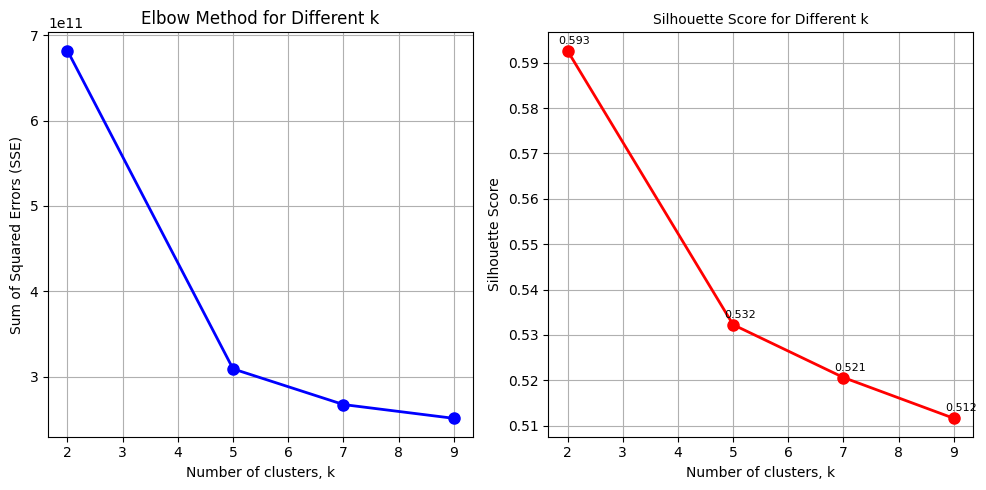

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Elbow Method
axes[0].plot(ks, sse, '-o', color='b', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of clusters, k', fontsize=10)
axes[0].set_ylabel('Sum of Squared Errors (SSE)', fontsize=10)
axes[0].set_title('Elbow Method for Different k', fontsize=12)
axes[0].grid(True)

# Silhouette Score
axes[1].plot(ks, silhouette_scores, '-o', color='r', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of clusters, k', fontsize=10)
axes[1].set_ylabel('Silhouette Score', fontsize=10)
axes[1].set_title('Silhouette Score for Different k', fontsize=10)
axes[1].grid(True)
for i, txt in enumerate(silhouette_scores):
    axes[1].annotate(f'{txt:.3f}', (ks[i], silhouette_scores[i]), textcoords="offset points", xytext=(5,5), ha='center', fontsize=8)

plt.tight_layout()
fig.savefig('2_1.png')
plt.show()

#### "Optimal number of clusters based on Elbow Method is: 5"
#### "Silhouette score is maximum for k = 2, Hence, optimal number of clusters is: 2"

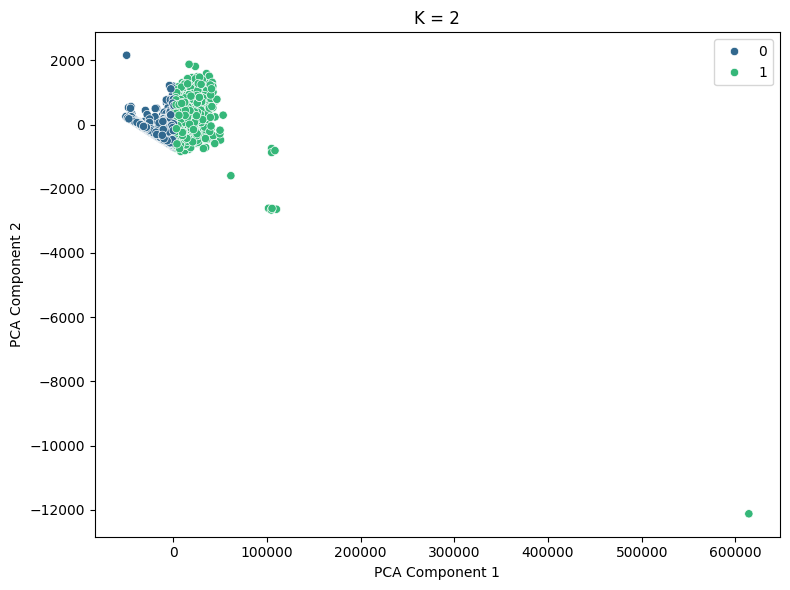

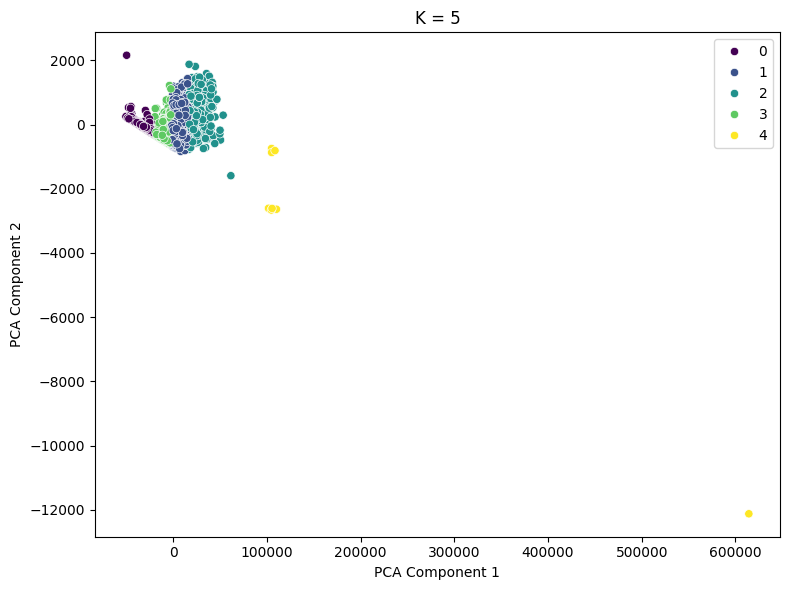

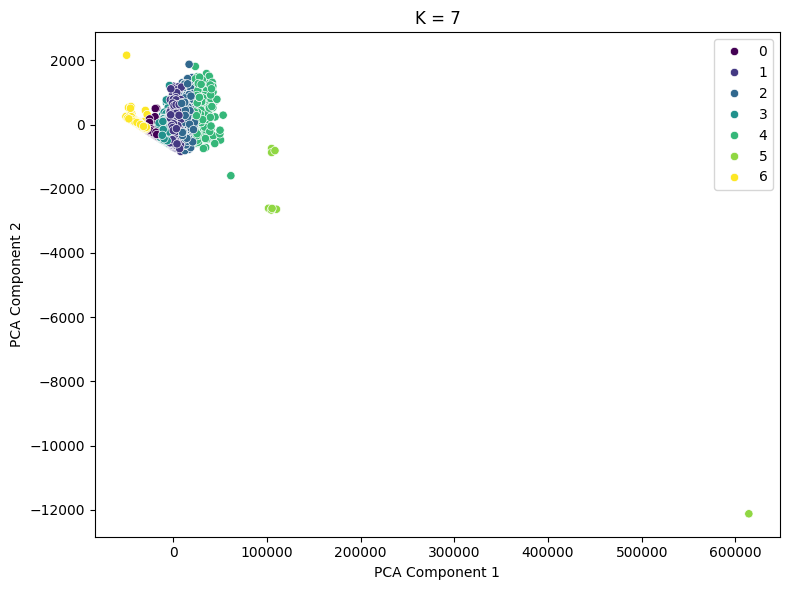

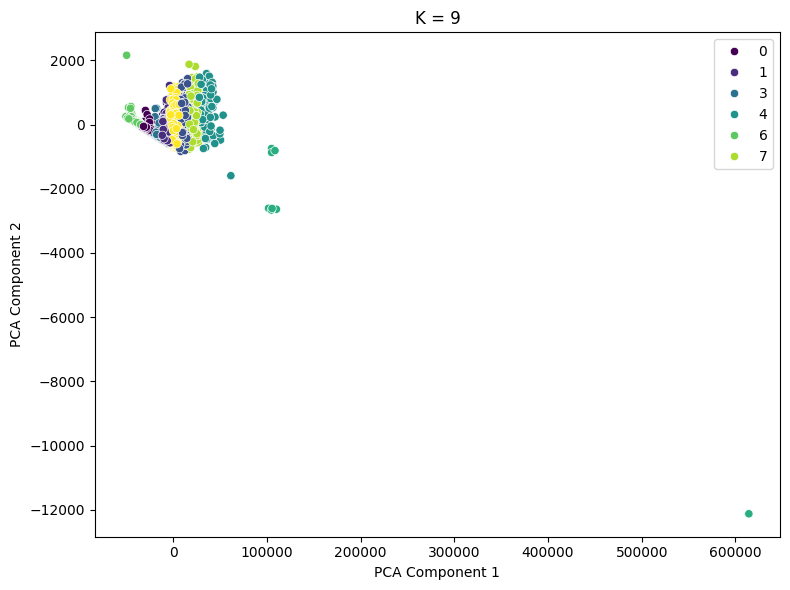

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
ks = [2, 5, 7, 9]
for k in ks:
    kmeans = KMeansAlgo(k=k)
    kmeans.fit(X)
    labels = kmeans.predict(X)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='viridis')
    plt.title(f'K = {k}')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.tight_layout()
    plt.savefig(f'2_2_k{k}.png')
    plt.show()